In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

In [2]:
class PolynomialFeatures:
  def __init__(self, deg, a) -> None:
    self.a = a
    self.deg = deg

  def transform(self, X):
    exponents = []
    n = len(X.columns)

    for d in range(self.deg+1):
      results = [p for p in itertools.product(range(d+1), repeat=n) if sum(p) == d]
      for s in results:
        exponents.append(s)

    new_X = pd.DataFrame(index=X.index)

    for exp in exponents:
      col_name = " * ".join([f"{col}^{p}" for col, p in zip(X.columns, exp)])
      val = 1
      for col, p in zip(X.columns, exp):
        val *= X[col] ** p
      new_X[col_name] = val

    self.data_columns = new_X.columns

    return new_X

  def hypo_func(self, x):
    return np.asarray(x) @ self.Q

  def loss_func(self, X, Y):
    preds = X @ self.Q
    errors = preds - Y
    return float((errors.T @ errors) / (2 * X.shape[0]))

  def gradient_descent(self, X, Y):
    preds = X @ self.Q
    grad = (X.T @ (preds - Y)) / (X.shape[0])
    self.Q -= self.a * grad

  def predict(self, x):
    x = self.transform(x)
    result = self.hypo_func(x)
    return pd.Series(result)

  def fit(self, X, Y, criteria, logs=True, max_iter=10000):
    X = self.transform(X).values
    Y = np.asarray(Y).flatten()
    self.Q = np.zeros(X.shape[1])
    iter = 1
    old_loss, curr_loss = None, self.loss_func(X, Y)

    self.history = {}
    while (old_loss==None or curr_loss==None or np.abs(old_loss-curr_loss)>criteria) and (iter<max_iter):
      self.gradient_descent(X, Y)
      old_loss = curr_loss
      curr_loss = self.loss_func(X, Y)
      self.history[iter] = curr_loss

      if logs:
        print(f"Loss {iter}:", curr_loss)

      iter += 1

    print("Model is trained.")

  def get_weights(self):
    weights = pd.Series(self.Q, index=self.data_columns)
    return weights

In [3]:
x1 = np.linspace(1,50,101)
x2 = np.linspace(1,20,101)
y = x1 ** 2 + x2 ** 3 + np.random.uniform(-5,5, 101)
df = pd.DataFrame({
    "x1":x1,
    "x2":x2,
    "y":y
})
df.head()

,x1,x2,y
0,1.00,1.00,6.426255
1,1.49,1.19,7.230606
2,1.98,1.38,3.720713
3,2.47,1.57,8.050144
4,2.96,1.76,13.089778


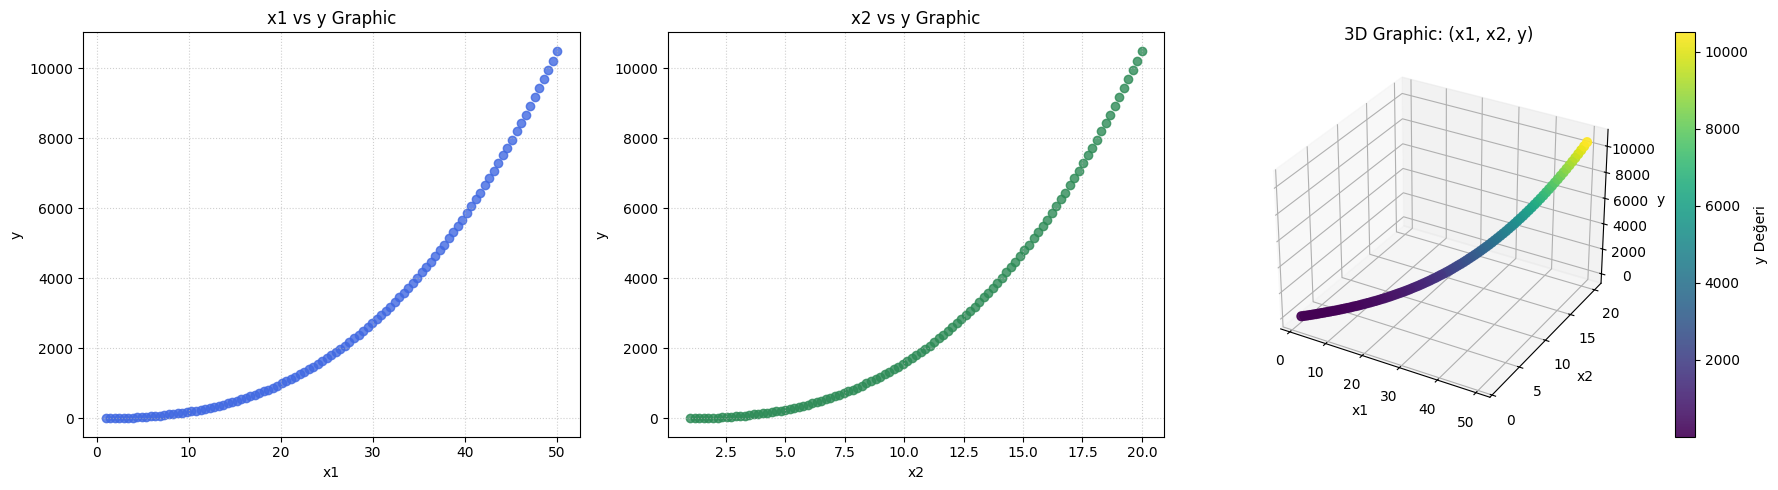

In [4]:
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(df['x1'], df['y'], color='royalblue', alpha=0.8)
ax1.set_title("x1 vs y Graphic")
ax1.set_xlabel("x1")
ax1.set_ylabel("y")
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(df['x2'], df['y'], color='seagreen', alpha=0.8)
ax2.set_title("x2 vs y Graphic")
ax2.set_xlabel("x2")
ax2.set_ylabel("y")
ax2.grid(True, linestyle=':', alpha=0.6)

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
scatter = ax3.scatter(df['x1'], df['x2'], df['y'], c=df['y'], cmap='viridis', s=40, alpha=0.9)
ax3.set_title("3D Graphic: (x1, x2, y)")
ax3.set_xlabel("x1")
ax3.set_ylabel("x2")
ax3.set_zlabel("y")

fig.colorbar(scatter, ax=ax3, label='y Değeri', pad=0.1)

plt.tight_layout()
plt.show()

In [5]:
X = df.drop(columns="y")
Y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
X_train.head()

,x1,x2
83,41.67,16.77
100,50.00,20.00
52,26.48,10.88
17,9.33,4.23
14,7.86,3.66


In [6]:
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns=X_train.columns)
X_train_scaled.head()

,x1,x2
0,0.83,0.83
1,1.00,1.00
2,0.52,0.52
3,0.17,0.17
4,0.14,0.14


In [7]:
print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)

X_train shape: (80, 2)
y_train shape: (80,)


In [8]:
model = PolynomialFeatures(deg=3, a=0.5)
model.fit(X_train_scaled, y_train, criteria=0.01)

Loss 1: 1076441.2457657168
Loss 2: 556445.6379402498
Loss 3: 387552.87363853696
Loss 4: 277700.27481287986
Loss 5: 201287.97539896215
Loss 6: 147877.37190091825
Loss 7: 110497.21875347776
Loss 8: 84298.54643861603
Loss 9: 65900.15303736336
Loss 10: 52943.95309339056
Loss 11: 43785.367188898876
Loss 12: 37277.41849579852
Loss 13: 32620.1614386567
Loss 14: 29255.672492327885
Loss 15: 26794.816213150792
Loss 16: 24966.171480462966
Loss 17: 23580.41238305503
Loss 18: 22505.46725479198
Loss 19: 21649.194447165104
Loss 20: 20947.300313081294
Loss 21: 20354.913135955932
Loss 22: 19840.706734073297
Loss 23: 19382.8022217922
Loss 24: 18965.909866672206
Loss 25: 18579.33579605748
Loss 26: 18215.59185429976
Loss 27: 17869.42610051357
Loss 28: 17537.146663371892
Loss 29: 17216.15018477746
Loss 30: 16904.592945030592
Loss 31: 16601.161494966538
Loss 32: 16304.912684921477
Loss 33: 16015.16209155733
Loss 34: 15731.406197753404
Loss 35: 15453.26811220788
Loss 36: 15180.459705899837
Loss 37: 14912.755

Text(0, 0.5, 'loss')

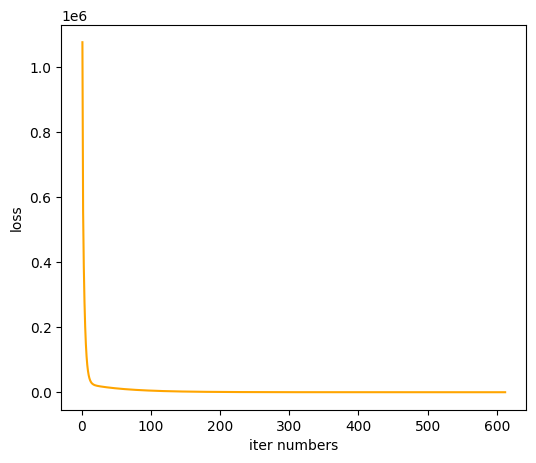

In [9]:
plt.figure(figsize=(6,5))
plt.plot(model.history.keys(),model.history.values(), c="orange")
plt.xlabel("iter numbers")
plt.ylabel("loss")

In [10]:
model.get_weights()

,0
x1^0 * x2^0,1.048141
x1^0 * x2^1,80.739608
x1^1 * x2^0,80.739608
x1^0 * x2^2,1158.262051
x1^1 * x2^1,1158.262051
x1^2 * x2^0,1158.262051
x1^0 * x2^3,1715.642072
x1^1 * x2^2,1715.642072
x1^2 * x2^1,1715.642072
x1^3 * x2^0,1715.642072


In [11]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:10])
print("MSE Score:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

0    9429.992322
1    4170.589729
2    1060.809982
3    6863.313219
4    4480.082206
5      18.666888
6    6655.971465
7    1808.305323
8    4021.229932
9    8676.521195
dtype: float64
MSE Score: 8.543609646025958
R2 Score: 0.999999154831604


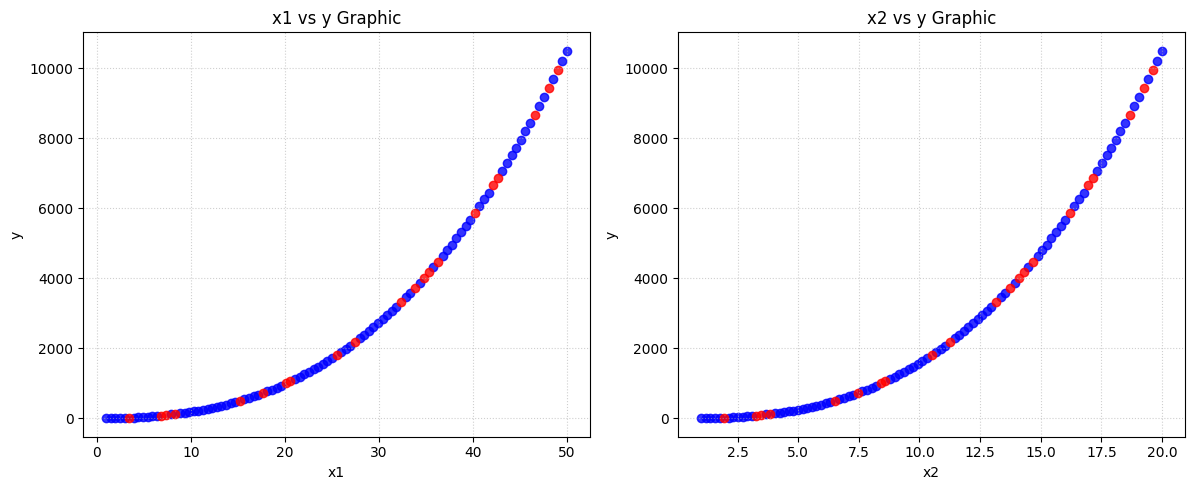

In [12]:
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(X_train["x1"], y_train, color='blue', alpha=0.8, label='Data')
ax1.scatter(X_test["x1"], y_pred, color='red', alpha=0.8, label='Predictions')
ax1.set_title("x1 vs y Graphic")
ax1.set_xlabel("x1")
ax1.set_ylabel("y")
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(X_train["x2"], y_train, color='blue', alpha=0.8, label='Data')
ax2.scatter(X_test["x2"], y_pred, color='red', alpha=0.8, label='Predictions')
ax2.set_title("x2 vs y Graphic")
ax2.set_xlabel("x2")
ax2.set_ylabel("y")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()